# Evaluation Pipeline - Google Cloud Notebook
This notebook runs the LLM generation and evaluation pipeline on Vertex AI, displaying metrics and aggregate results directly within the notebook.

In [1]:
# 1. Check & Install Dependencies
!pip install -q -r requirements.txt python-dotenv pandas matplotlib

You should consider upgrading via the '/Users/vanessrw/Desktop/renbee_july/ThesisNessy/venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
# 2. Load Environment / Configure GCP Project
import os
from pathlib import Path
from dotenv import load_dotenv

if Path(".env").exists():
    load_dotenv()
    print("Loaded .env configuration")
else:
    print("No .env file found. Ensure GCP Application Default Credentials (ADC) are configured.")

print("GCP Project:", os.getenv("GOOGLE_CLOUD_PROJECT", "Not Set"))
print("LLM Base:", os.getenv("LLM_API_BASE", "Not Set"))

Loaded .env configuration
GCP Project: renbee-500415
LLM Base: https://us-central1-aiplatform.googleapis.com/v1beta1/projects/renbee-500415/locations/us-central1/endpoints/openapi


In [3]:
# 3. Run Evaluation Harness
# Change flags as needed:
# Use '--mock-gen --mock-judge' for offline smoke test
# Use '--repeats 3 --regenerate' for full production run on Vertex AI

!python -m evaluation.run_eval --mock-gen --mock-judge

Cases: 30 | generator: mock | judge: mock | repeats: 1
Generating outputs...
Scoring...

Wrote /Users/vanessrw/Desktop/renbee/main/eval_outputs/scores.json and /Users/vanessrw/Desktop/renbee/main/eval_outputs/summary.csv

=== AGGREGATE SUMMARY ===
  (std = between-case; within = mean spread across repeats of a case)
  completeness.score                         mean=0.998  std=0.013  within=--  n_cases=30  n_obs=30
  rfq.preservation_rate                      mean=1.0  std=0.0  within=--  n_cases=30  n_obs=30
  rfq.fabrication_rate                       mean=0.0  std=0.0  within=--  n_cases=30  n_obs=30
  rfq.fabricated_statements                  mean=0  std=0.0  within=--  n_cases=30  n_obs=30
  rfq.total_statements                       mean=8  std=0.0  within=--  n_cases=30  n_obs=30
  rfq.clarity                                mean=4  std=0.0  within=--  n_cases=30  n_obs=30
  rfq.usability                              mean=4  std=0.0  within=--  n_cases=30  n_obs=30
  rfq.perceive

In [4]:
# 4. Display Aggregated Summary Table
import pandas as pd
from IPython.display import display

summary_path = Path("eval_outputs/summary.csv")
if summary_path.exists():
    df = pd.read_csv(summary_path)
    print("=== Evaluation Summary Table ===")
    display(df)
else:
    print("eval_outputs/summary.csv not found. Run evaluation step first.")

=== Evaluation Summary Table ===


,metric,mean,std_between_case,std_within_case,n_cases,n_obs
0,completeness.score,0.998,0.013,NaN,30,30
1,rfq.preservation_rate,1.000,0.000,NaN,30,30
2,rfq.fabrication_rate,0.000,0.000,NaN,30,30
3,rfq.fabricated_statements,0.000,0.000,NaN,30,30
4,rfq.total_statements,8.000,0.000,NaN,30,30
5,rfq.site_context_coverage,0.268,0.368,NaN,28,28
6,rfq.clarity,4.000,0.000,NaN,30,30
7,rfq.usability,4.000,0.000,NaN,30,30
8,rfq.perceived_efficiency,4.000,0.000,NaN,30,30
9,recommendation.preservation_rate,0.793,0.405,NaN,29,29


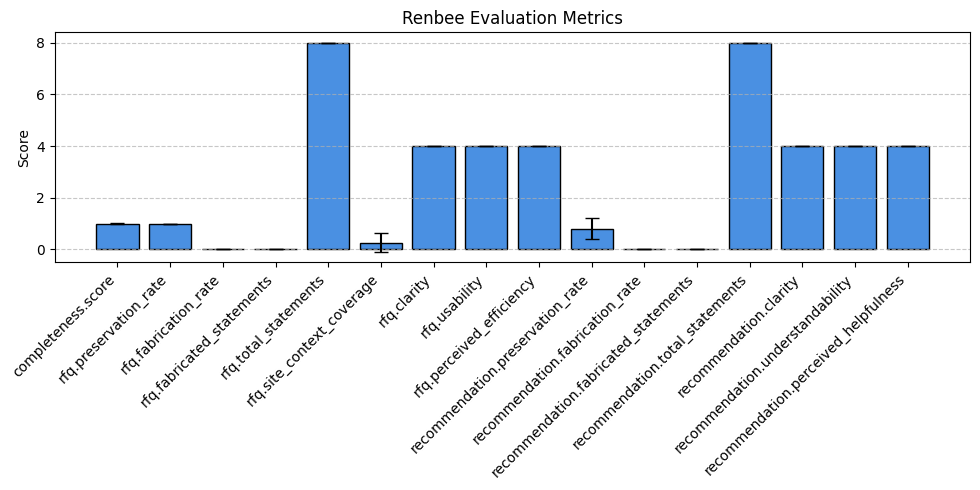

In [5]:
# 5. Plot Scores & Standard Deviations
import matplotlib.pyplot as plt

if summary_path.exists():
    plt.figure(figsize=(10, 5))
    plt.bar(df['metric'], df['mean'], yerr=df.get('std_between_case', 0), capsize=5, color='#4A90E2', edgecolor='black')
    plt.title("Renbee Evaluation Metrics")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()